# Evolution Strategy 进化策略

## 本 Notebook 的教学目标

1. 理解该算法的搜索直觉。
2. 使用一个经典二维优化问题完成从零实现。
3. 通过可视化观察算法如何移动、如何收敛、可能会遇到什么问题。
4. 通过多次运行和参数实验建立更稳固的算法直觉。

## 实验问题

本实验使用 **Rosenbrock 函数**。它的狭长谷底非常适合演示进化策略如何通过群体采样逐步逼近最优区域。

在教学上，二维问题有一个明显优势：**我们可以直接把搜索轨迹画出来**。这比只看一串数值更适合课堂演示。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 统一图表风格，保证讲课时图表更清晰。
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# 本项目统一使用二维测试函数，这样可以把搜索轨迹直接画在等高线上。

def make_grid(bounds, step=250):
    xs = np.linspace(bounds[0, 0], bounds[0, 1], step)
    ys = np.linspace(bounds[1, 0], bounds[1, 1], step)
    xx, yy = np.meshgrid(xs, ys)
    return xs, ys, xx, yy


def evaluate_on_grid(objective, bounds, step=250):
    xs, ys, xx, yy = make_grid(bounds, step=step)
    zz = np.vectorize(lambda a, b: objective(np.array([a, b])))(xx, yy)
    return xs, ys, xx, yy, zz


def plot_contour_with_trace(objective, bounds, trace, title, levels=40):
    xs, ys, xx, yy, zz = evaluate_on_grid(objective, bounds)
    plt.figure(figsize=(9, 7))
    contour = plt.contourf(xx, yy, zz, levels=levels, cmap='viridis')
    plt.colorbar(contour, label='Objective value')

    trace = np.array(trace)
    plt.plot(trace[:, 0], trace[:, 1], color='white', lw=2, alpha=0.9, label='Search trace')
    plt.scatter(trace[:, 0], trace[:, 1], c=np.arange(len(trace)), cmap='coolwarm', s=40, edgecolor='black')
    plt.scatter(trace[0, 0], trace[0, 1], color='gold', s=120, marker='o', edgecolor='black', label='Start')
    plt.scatter(trace[-1, 0], trace[-1, 1], color='red', s=160, marker='*', edgecolor='black', label='End / Best')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()


def summarize_runs(scores):
    return pd.Series({
        'best': float(np.min(scores)),
        'mean': float(np.mean(scores)),
        'worst': float(np.max(scores)),
        'std': float(np.std(scores)),
    })


# Rosenbrock 函数的全局最优在 (1, 1)，但到达这条狭长谷底并不容易。
def objective(point):
    x, y = point
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2

bounds = np.array([[-2.5, 2.5], [-1.5, 3.0]], dtype=float)

## 算法直觉

核心思想：维护一小批父代个体，让每个父代产生多个带随机扰动的子代，再从中筛选出新的父代。

为了让课堂节奏更清楚，Notebook 里的实现会优先追求**可读性**，而不是极端性能优化。

In [2]:
# 这里实现一个教学版 (mu, lambda)-ES，并记录每一代群体位置用于可视化。
def evolution_strategy(objective, bounds, mu=8, offspring_per_parent=6, n_generations=50, sigma=0.4, seed=0):
    rng = np.random.default_rng(seed)
    parents = rng.uniform(bounds[:, 0], bounds[:, 1], size=(mu, len(bounds)))
    parent_scores = np.apply_along_axis(objective, 1, parents)

    history = [parents.copy()]
    best_scores = [float(parent_scores.min())]
    sigma_history = [sigma]

    for _ in range(n_generations):
        offspring = []
        for parent in parents:
            # 每个父代周围采样多个子代，体现局部探索与群体并行搜索。
            children = parent + rng.normal(0, sigma, size=(offspring_per_parent, len(bounds)))
            offspring.append(children)
        offspring = np.vstack(offspring)
        offspring = np.clip(offspring, bounds[:, 0], bounds[:, 1])
        offspring_scores = np.apply_along_axis(objective, 1, offspring)

        # 选出表现最好的 mu 个子代作为下一代父代。
        best_indices = np.argsort(offspring_scores)[:mu]
        parents = offspring[best_indices]
        parent_scores = offspring_scores[best_indices]

        # 用简单的成功率思想粗略调节 sigma，便于教学中讲解“步长控制”。
        improvement = best_scores[-1] - float(parent_scores.min())
        if improvement > 1e-3:
            sigma *= 1.02
        else:
            sigma *= 0.92
        sigma = float(np.clip(sigma, 0.05, 1.2))

        history.append(parents.copy())
        best_scores.append(float(parent_scores.min()))
        sigma_history.append(sigma)

    best_idx = int(np.argmin(parent_scores))
    return {
        'best': parents[best_idx],
        'best_score': float(parent_scores[best_idx]),
        'history': history,
        'best_scores': np.array(best_scores),
        'sigma_history': np.array(sigma_history),
    }

## 单次实验演示

下面先运行一次实验，重点观察两件事：

1. 搜索轨迹是否平滑、是否容易停在局部区域。
2. 目标值是否快速下降，以及下降到什么程度后开始停滞。

best point: [0.7497 0.5649]
best score: 0.063463


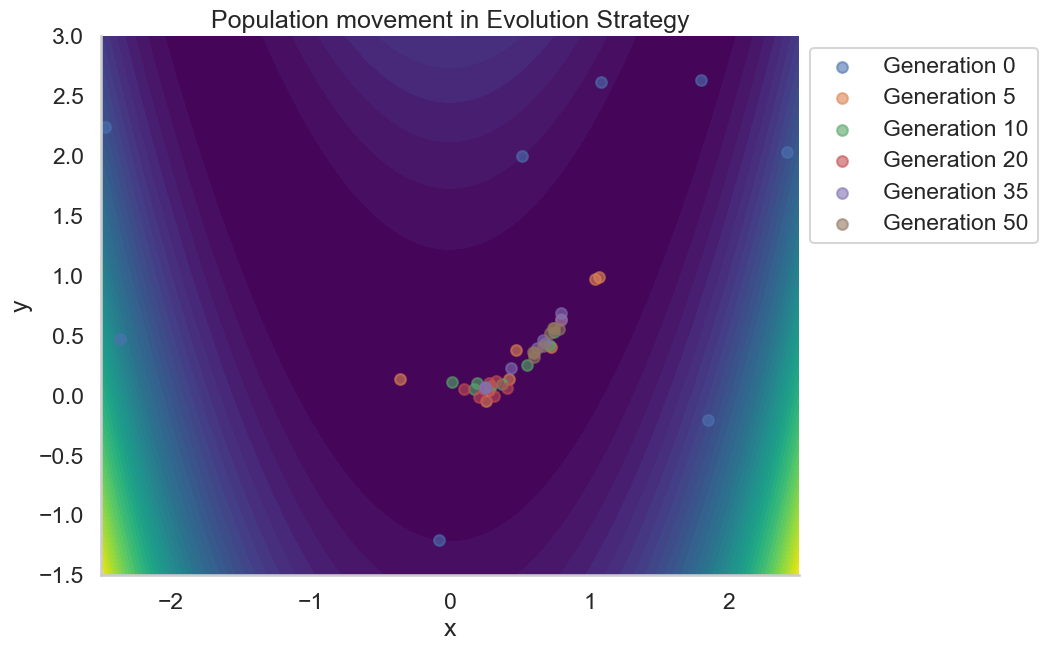

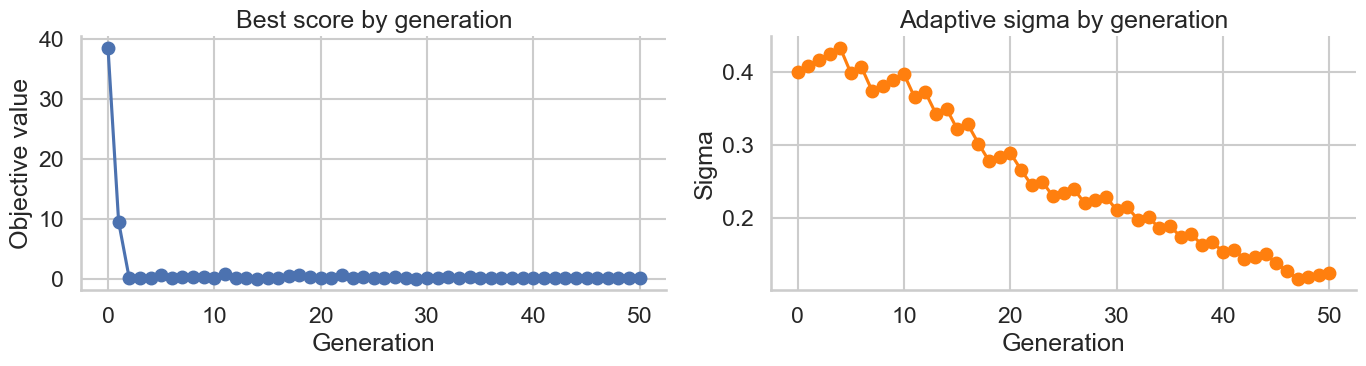

In [3]:
es_result = evolution_strategy(objective, bounds, seed=9)
print('best point:', np.round(es_result['best'], 4))
print('best score:', round(es_result['best_score'], 6))

# 只展示部分代数的群体位置，避免图面过于拥挤。
xs, ys, xx, yy, zz = evaluate_on_grid(objective, bounds)
plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, zz, levels=40, cmap='viridis')
for idx in [0, 5, 10, 20, 35, 50]:
    population = es_result['history'][idx]
    plt.scatter(population[:, 0], population[:, 1], s=60, alpha=0.6, label=f'Generation {idx}')
plt.title('Population movement in Evolution Strategy')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(es_result['best_scores'], marker='o')
axes[0].set_title('Best score by generation')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Objective value')
axes[1].plot(es_result['sigma_history'], marker='o', color='tab:orange')
axes[1].set_title('Adaptive sigma by generation')
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Sigma')
plt.tight_layout()
plt.show()

## 多次运行与参数分析

单次实验只能告诉我们“这一次发生了什么”，但讲课时更重要的是说明：

1. 算法是否稳定。
2. 算法是否依赖初始条件。
3. 关键参数变化后，会如何影响最终表现。

,Evolution Strategy statistics
best,0.005425
mean,0.033499
worst,0.079259
std,0.024494


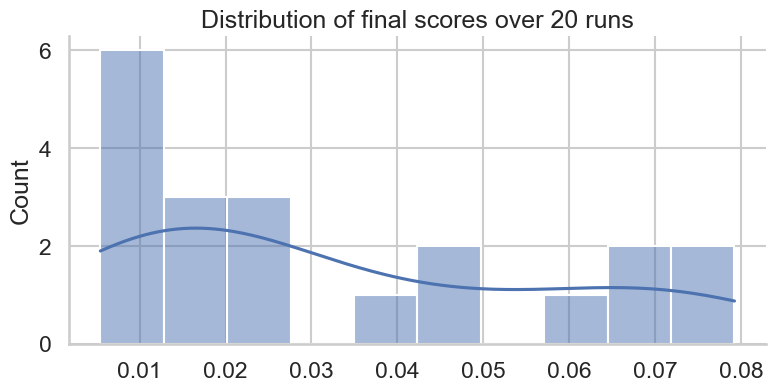

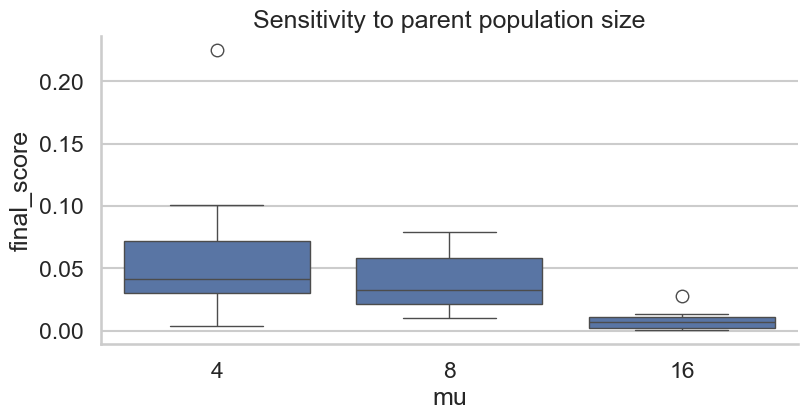

In [4]:
# 多次运行统计，观察该算法在 Rosenbrock 上的稳定性。
run_scores = [evolution_strategy(objective, bounds, seed=seed)['best_score'] for seed in range(20)]
display(summarize_runs(run_scores).to_frame(name='Evolution Strategy statistics'))

plt.figure(figsize=(9, 4))
sns.histplot(run_scores, bins=10, kde=True)
plt.title('Distribution of final scores over 20 runs')
plt.show()

# 参数敏感性：mu 决定父代规模，过小会影响多样性，过大又会增加计算量。
mu_values = [4, 8, 16]
records = []
for mu in mu_values:
    for seed in range(10):
        score = evolution_strategy(objective, bounds, mu=mu, seed=seed)['best_score']
        records.append({'mu': mu, 'final_score': score})

param_df = pd.DataFrame(records)
plt.figure(figsize=(9, 4))
sns.boxplot(data=param_df, x='mu', y='final_score')
plt.title('Sensitivity to parent population size')
plt.show()

## 课堂总结

讲解这一类算法时，建议把重点放在以下问题上：

1. 算法的探索能力来自哪里。
2. 算法的利用能力来自哪里。
3. 它最容易失败的场景是什么。
4. 参数变化时，算法行为为什么会改变。

把这四个问题讲清楚，学生通常就能真正建立算法直觉。